In [1]:
import pandas as pd
from holoviews.plotting.bokeh.styles import font_size

file = '/Users/JenniferChan/Documents/Data399/Bullying_2018 Right.csv'
df = pd.read_csv(file)
df

,record,Bullied_on_school_property_in_past_12_months,Age,Sex,Felt Lonely,Close Friends,Other Students Kind and Helpful
0,1,Yes,13 years old,Female,Always,2,Never
1,2,No,13 years old,Female,Never,3 or more,Sometimes
2,3,No,14 years old,Male,Never,3 or more,Sometimes
3,4,No,16 years old,Male,Never,3 or more,Sometimes
4,5,No,13 years old,Female,Rarely,3 or more,Most of the time
...,...,...,...,...,...,...,...
56976,57091,No,16 years old,Male,Sometimes,3 or more,Sometimes
56977,57092,No,16 years old,Male,Rarely,1,Sometimes
56978,57093,No,16 years old,Male,Sometimes,3 or more,Rarely
56979,57094,No,16 years old,Female,Sometimes,2,Most of the time


In [2]:
df.isnull().sum()

record                                          0
Bullied_on_school_property_in_past_12_months    0
Age                                             0
Sex                                             0
Felt Lonely                                     0
Close Friends                                   0
Other Students Kind and Helpful                 0
dtype: int64

In [3]:
# Remove rows with any missing values
df_clean = df.dropna()
df_clean

,record,Bullied_on_school_property_in_past_12_months,Age,Sex,Felt Lonely,Close Friends,Other Students Kind and Helpful
0,1,Yes,13 years old,Female,Always,2,Never
1,2,No,13 years old,Female,Never,3 or more,Sometimes
2,3,No,14 years old,Male,Never,3 or more,Sometimes
3,4,No,16 years old,Male,Never,3 or more,Sometimes
4,5,No,13 years old,Female,Rarely,3 or more,Most of the time
...,...,...,...,...,...,...,...
56976,57091,No,16 years old,Male,Sometimes,3 or more,Sometimes
56977,57092,No,16 years old,Male,Rarely,1,Sometimes
56978,57093,No,16 years old,Male,Sometimes,3 or more,Rarely
56979,57094,No,16 years old,Female,Sometimes,2,Most of the time


In [4]:
df_clean.isnull().sum()

record                                          0
Bullied_on_school_property_in_past_12_months    0
Age                                             0
Sex                                             0
Felt Lonely                                     0
Close Friends                                   0
Other Students Kind and Helpful                 0
dtype: int64

In [5]:
df_clean.duplicated().sum()

np.int64(0)

In [6]:
print(df_clean.duplicated(subset=['record']))

0        False
1        False
2        False
3        False
4        False
         ...  
56976    False
56977    False
56978    False
56979    False
56980    False
Length: 56981, dtype: bool


In [7]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56981 entries, 0 to 56980
Data columns (total 7 columns):
 #   Column                                        Non-Null Count  Dtype 
---  ------                                        --------------  ----- 
 0   record                                        56981 non-null  int64 
 1   Bullied_on_school_property_in_past_12_months  56981 non-null  object
 2   Age                                           56981 non-null  object
 3   Sex                                           56981 non-null  object
 4   Felt Lonely                                   56981 non-null  object
 5   Close Friends                                 56981 non-null  object
 6   Other Students Kind and Helpful               56981 non-null  object
dtypes: int64(1), object(6)
memory usage: 3.0+ MB


In [8]:
df_clean["Bullied_on_school_property_in_past_12_months"].unique()



array(['Yes', 'No', ' '], dtype=object)

In [9]:
df_clean = df_clean[df_clean["Bullied_on_school_property_in_past_12_months"].str.strip() != ""]

In [10]:
df_clean = df_clean[df_clean["Age"].str.strip() != ""]

In [11]:
df_clean["Age"].unique()

array(['13 years old', '14 years old', '16 years old', '12 years old',
       '15 years old', '11 years old or younger', '17 years old',
       '18 years old or older'], dtype=object)

In [12]:
df_clean = df_clean[df_clean["Sex"].str.strip() != ""]


In [13]:
df_clean["Sex"].unique()

array(['Female', 'Male'], dtype=object)

In [14]:
df_clean = df_clean[df_clean["Felt Lonely"].str.strip() != ""]

In [15]:
df_clean["Felt Lonely"].unique()

array(['Always', 'Never', 'Rarely', 'Sometimes', 'Most of the time'],
      dtype=object)

In [16]:
df_clean = df_clean[df_clean["Close Friends"].str.strip() != ""]


In [17]:
df_clean["Close Friends"].unique()

array(['2', '3 or more', '0', '1'], dtype=object)

In [18]:
df_clean = df_clean[df_clean["Other Students Kind and Helpful"].str.strip() != ""]


In [19]:
df_clean["Other Students Kind and Helpful"].unique()

array(['Never', 'Sometimes', 'Most of the time', 'Always', 'Rarely',
       'Most of the tim', 'Most of th', 'Alway', 'Rarel', 'Sometime',
       'Most of the t', 'Most of the ti', 'Most of the', 'Someti',
       'Most of t', 'Sometim', 'Most', 'Neve', 'Rar', 'Most of'],
      dtype=object)

In [20]:
def clean_response(x):
    if x.startswith('Neve'):
        return 'Never'
    elif x.startswith('Rar'):
        return 'Rarely'
    elif x.startswith('Some'):
        return 'Sometimes'
    elif x.startswith('Most'):
        return 'Most of the time'
    elif x.startswith('Alway'):
        return 'Always'
    else:
        return x

df_clean['Other Students Kind and Helpful'] = df_clean['Other Students Kind and Helpful'].apply(clean_response)

In [21]:
df_clean["Other Students Kind and Helpful"].unique()


array(['Never', 'Sometimes', 'Most of the time', 'Always', 'Rarely'],
      dtype=object)

In [22]:
age_order = [
    '11 years old or younger',
    '12 years old',
    '13 years old',
    '14 years old',
    '15 years old',
    '16 years old',
    '17 years old',
    '18 years old or older'
]

df_clean['Age'] = pd.Categorical(
    df_clean['Age'],
    categories=age_order,
    ordered=True
)

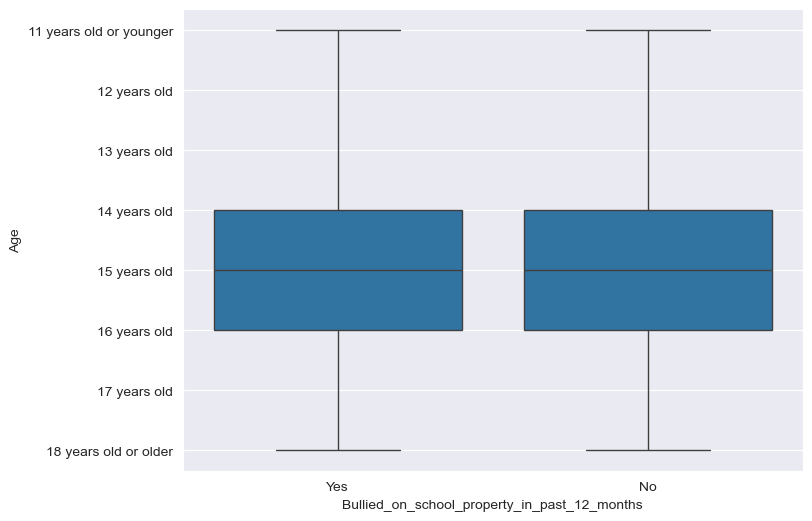

In [23]:
# Box plot
# Plot bullied on school property vs age
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_clean,
    x='Bullied_on_school_property_in_past_12_months',
    y='Age'
)
df_clean.groupby('Bullied_on_school_property_in_past_12_months')['Age'].describe()
plt.show()

In [24]:
df_clean.groupby('Bullied_on_school_property_in_past_12_months')['Age'].describe()

,count,unique,top,freq
Bullied_on_school_property_in_past_12_months,,,,
No,41601,8,15 years old,9337
Yes,11183,8,14 years old,2690


In [25]:
lonely_order = [
    'Never',
    'Rarely',
    'Sometimes',
    'Most of the time',
    'Always'
]

df_clean['Felt Lonely'] = pd.Categorical(
    df_clean['Felt Lonely'],
    categories=lonely_order,
    ordered=True
)

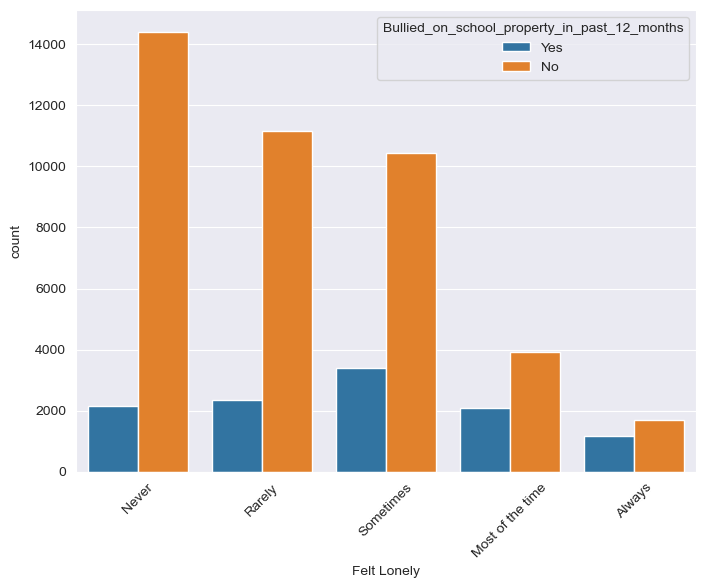

In [26]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=df_clean,
    x='Felt Lonely',
    hue='Bullied_on_school_property_in_past_12_months'
)

plt.xticks(rotation=45)
plt.show()

In [27]:
kind_order = [
    'Never',
    'Rarely',
    'Sometimes',
    'Most of the time',
    'Always'
]
df_clean['Other Students Kind and Helpful'] = pd.Categorical(
    df_clean['Other Students Kind and Helpful'],
    categories=kind_order,
    ordered=True
)

In [28]:
friends_order = [
    '0',
    '1',
    '2',
    '3 or more'
]
df_clean['Close Friends'] = pd.Categorical(
    df_clean['Close Friends'],
    categories=friends_order,
    ordered=True
)

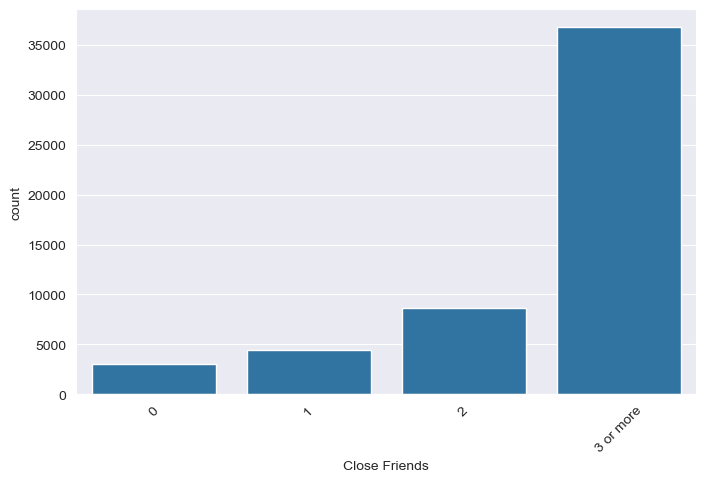

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x='Close Friends', order=[
    '0', '1', '2','3 or more'
])
plt.xticks(rotation=45)
plt.show()

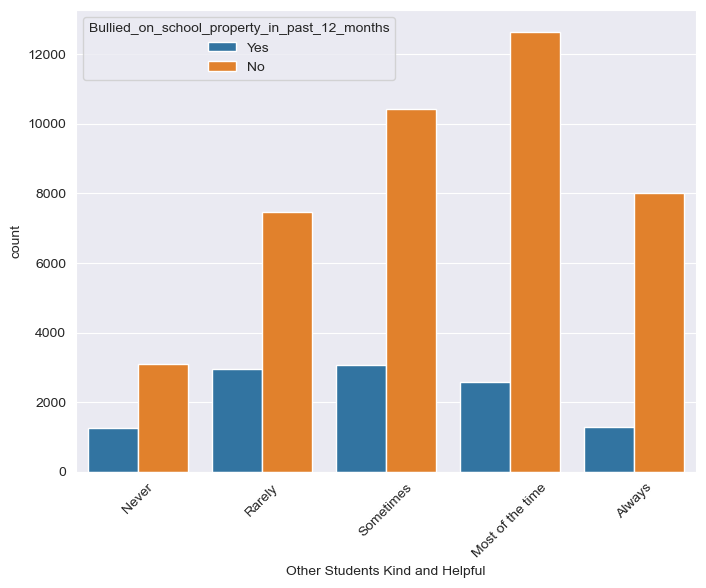

In [30]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=df_clean,
    x='Other Students Kind and Helpful',
    hue='Bullied_on_school_property_in_past_12_months'
)

plt.xticks(rotation=45)
plt.show()

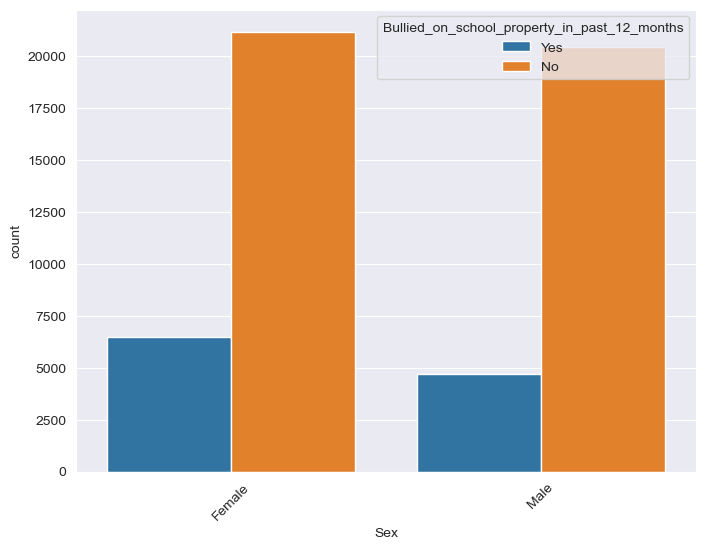

In [31]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=df_clean,
    x='Sex',
    hue='Bullied_on_school_property_in_past_12_months'
)

plt.xticks(rotation=45)
plt.show()

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

#Count
counts = df_clean['Bullied_on_school_property_in_past_12_months'].value_counts()
print(counts)

Bullied_on_school_property_in_past_12_months
No     41601
Yes    11183
Name: count, dtype: int64


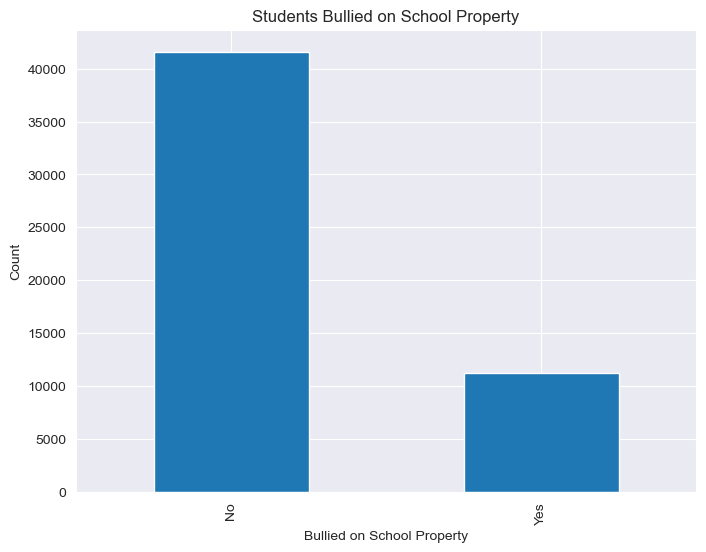

In [33]:
plt.figure(figsize=(8,6))
counts.plot(kind='bar')

plt.xlabel("Bullied on School Property")
plt.ylabel('Count')
plt.title('Students Bullied on School Property')
plt.show()

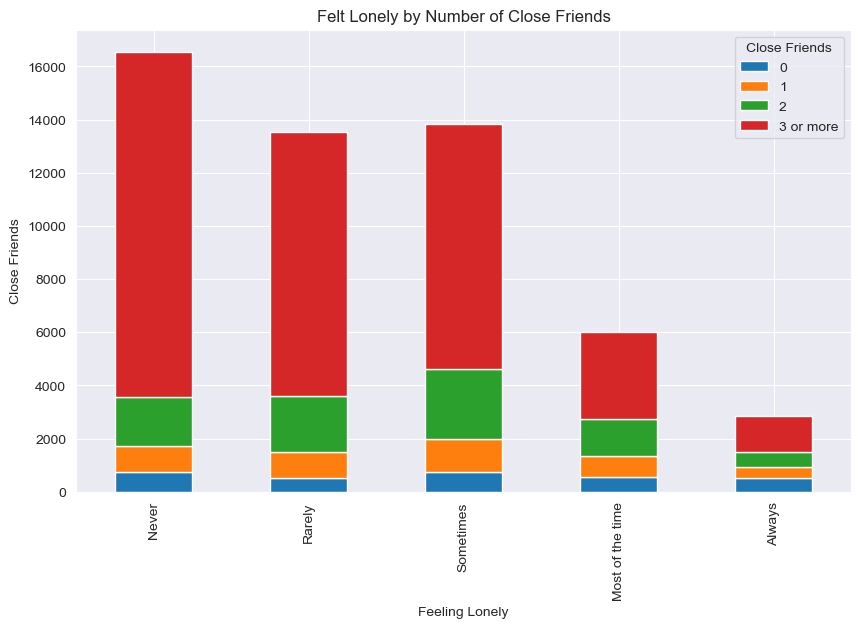

In [34]:
pd.crosstab(df_clean['Felt Lonely'], df_clean['Close Friends']).plot(
    kind='bar', stacked=True, figsize=(10,6)
)
plt.title('Felt Lonely by Number of Close Friends')
plt.xlabel('Feeling Lonely')
plt.ylabel('Close Friends')
plt.show()

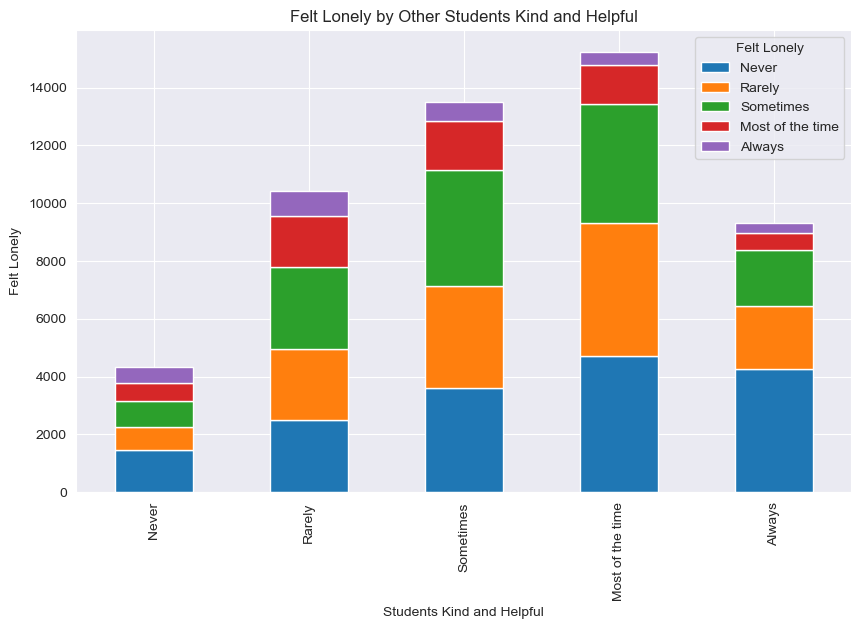

In [35]:
pd.crosstab(df_clean['Other Students Kind and Helpful'], df_clean['Felt Lonely']).plot(
    kind='bar', stacked=True, figsize=(10,6)
)
plt.title('Felt Lonely by Other Students Kind and Helpful')
plt.xlabel('Students Kind and Helpful')
plt.ylabel('Felt Lonely')
plt.show()

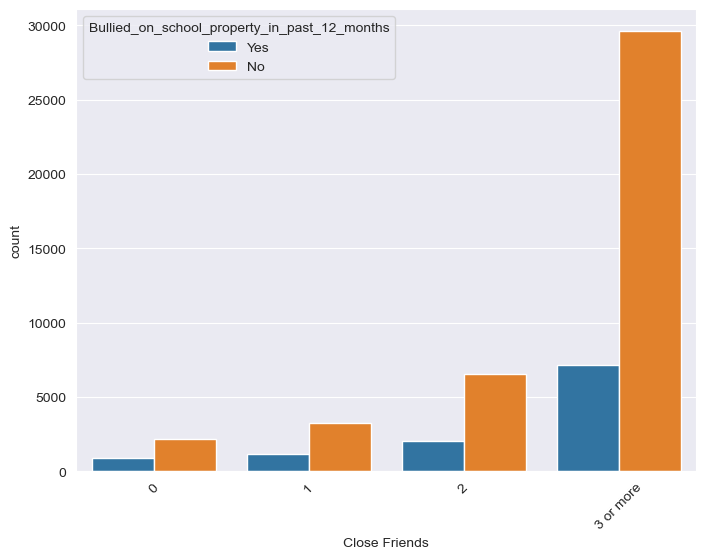

In [36]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=df_clean,
    x='Close Friends',
    hue='Bullied_on_school_property_in_past_12_months'
)

plt.xticks(rotation=45)
plt.show()

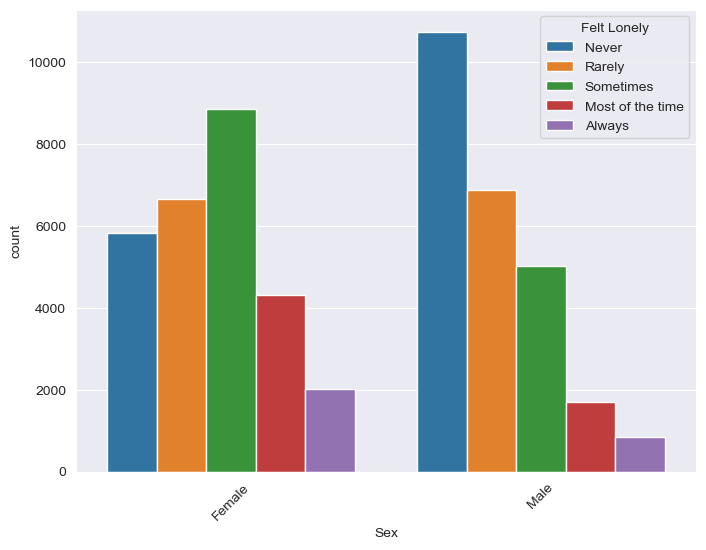

In [37]:
plt.show()
plt.figure(figsize=(8, 6))

sns.countplot(
    data=df_clean,
    x='Sex',
    hue='Felt Lonely'
)

plt.xticks(rotation=45)
plt.show()

In [38]:
df_clean['Felt Lonely'] = df_clean['Felt Lonely'].map({
    'Never': 1,
    'Rarely': 2,
    'Sometimes': 3,
    'Most of the time': 4,
    'Always': 5
})

df_clean['Bullied_on_school_property_in_past_12_months'] = df_clean['Bullied_on_school_property_in_past_12_months'].map({
    'No': 0,
    'Yes': 1
})

In [39]:
df_clean = df_clean.dropna(subset=['Felt Lonely', 'Bullied_on_school_property_in_past_12_months', 'Age'])

In [40]:
df_clean = pd.get_dummies(df_clean, columns=['Age'], drop_first=True)

In [41]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

X = df_clean[['Felt Lonely'] + [col for col in df_clean.columns if col.startswith('Age_')]]
y = df_clean['Bullied_on_school_property_in_past_12_months']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})
print(coefficients)

Accuracy: 0.7865870986075589
Confusion Matrix:
 [[8303    0]
 [2253    1]]
                     Feature  Coefficient
0                Felt Lonely     0.425991
1           Age_12 years old     0.005649
2           Age_13 years old    -0.031832
3           Age_14 years old    -0.123813
4           Age_15 years old    -0.309761
5           Age_16 years old    -0.419927
6           Age_17 years old    -0.554612
7  Age_18 years old or older    -0.622518


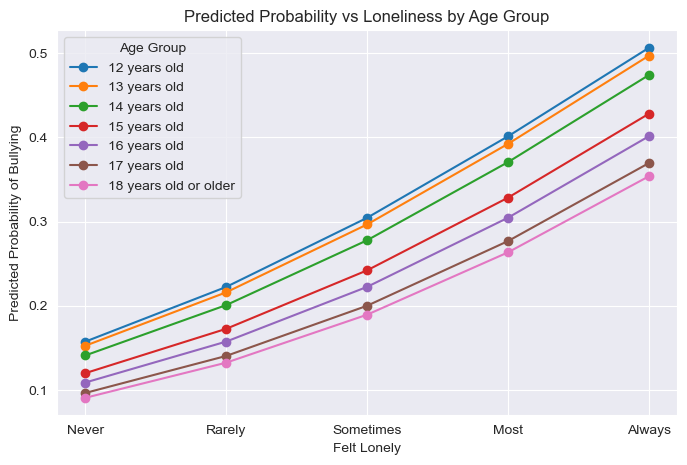

In [42]:
# Store probabilities
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
lonely_range = np.arange(1,6)

# Choose which age groups you want to compare
age_columns = [col for col in X.columns if 'Age_' in col]

plt.figure(figsize=(8,5))

for age_col in age_columns:
    probs = []

    for val in lonely_range:
        # Start with all zeros
        x_df = pd.DataFrame([np.zeros(len(X.columns))], columns=X.columns)

        # Set loneliness level
        x_df['Felt Lonely'] = val

        # Set ONE age group to 1, others remain 0
        x_df[age_col] = 1

        # Predict probability
        prob = model.predict_proba(x_df)[0,1]
        probs.append(prob)

    # Clean label (optional)
    label = age_col.replace('Age_', '')

    plt.plot(lonely_range, probs, marker='o', label=label)

# Formatting
plt.xticks(lonely_range, ['Never','Rarely','Sometimes','Most','Always'])
plt.xlabel('Felt Lonely')
plt.ylabel('Predicted Probability of Bullying')
plt.title('Predicted Probability vs Loneliness by Age Group')
plt.legend(title='Age Group')
plt.grid(True)
plt.show()

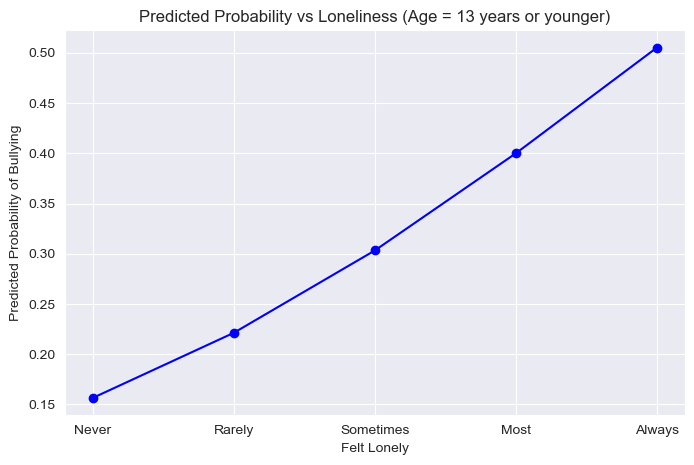

In [43]:
# Store probabilities
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loneliness levels 1–5
lonely_range = np.arange(1,6)

# Store probabilities
probs = []

for val in lonely_range:
    # Start with all zeros (baseline)
    x_df = pd.DataFrame([np.zeros(len(X.columns))], columns=X.columns)
    x_df['Felt Lonely'] = val

    # Set Age = 13 years
    # Find the correct dummy column name (check your X.columns)
    if 'Age_13 years' in X.columns:
        x_df['Age_13 years'] = 1  # set the dummy for 13 years old

    # Predict probability
    prob = model.predict_proba(x_df)[0,1]
    probs.append(prob)


# Plot
plt.figure(figsize=(8,5))
plt.plot(lonely_range, probs, marker='o', color='blue')
plt.xticks(lonely_range, ['Never','Rarely','Sometimes','Most','Always'])
plt.xlabel('Felt Lonely')
plt.ylabel('Predicted Probability of Bullying')
plt.title('Predicted Probability vs Loneliness (Age = 13 years or younger)')
plt.grid(True)
plt.show()

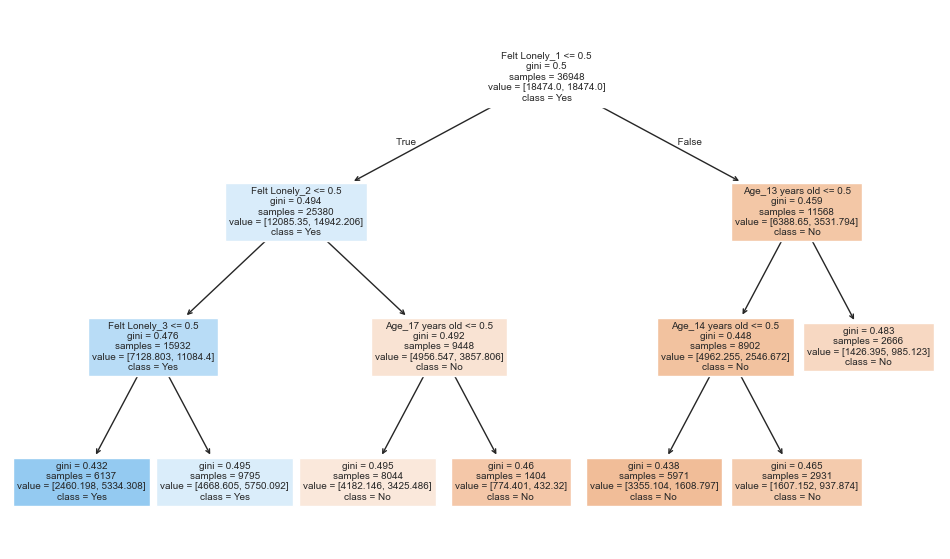

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Select variables
X = df_clean[['Felt Lonely'] + [col for col in df_clean.columns if col.startswith('Age_')]]
y = df_clean['Bullied_on_school_property_in_past_12_months']

# 2. Encode
X = pd.get_dummies(X, columns=['Felt Lonely'])
y = pd.get_dummies(y, drop_first=True).squeeze()

# 3. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = DecisionTreeClassifier(
    max_depth=3,            # fewer levels
    min_samples_leaf=200,   # fewer splits
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

# 5. Plot tree
plt.figure(figsize=(12, 7))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True
)
plt.show()

In [45]:
print(df_clean.columns)

Index(['record', 'Bullied_on_school_property_in_past_12_months', 'Sex',
       'Felt Lonely', 'Close Friends', 'Other Students Kind and Helpful',
       'Age_12 years old', 'Age_13 years old', 'Age_14 years old',
       'Age_15 years old', 'Age_16 years old', 'Age_17 years old',
       'Age_18 years old or older'],
      dtype='object')


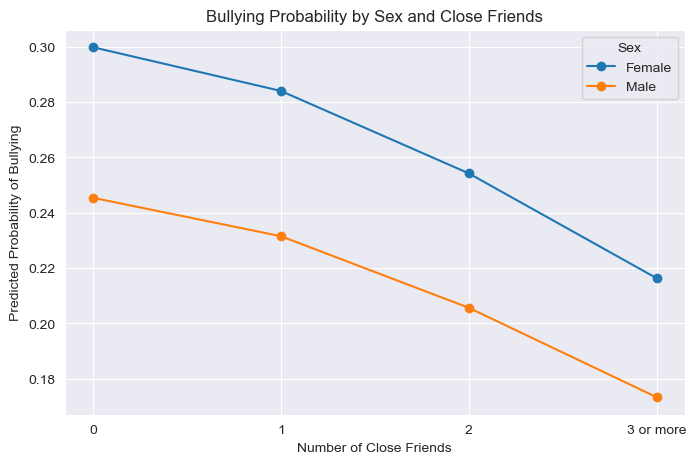

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Use only the variables you want
X = df_clean[['Sex', 'Close Friends']]
y = df_clean['Bullied_on_school_property_in_past_12_months']

# Encode categorical variables
X = pd.get_dummies(X)
y = pd.get_dummies(y, drop_first=True).squeeze()

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train logistic regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
friend_categories = sorted(df_clean['Close Friends'].unique())
sex_categories = df_clean['Sex'].unique()

plt.figure(figsize=(8,5))

for sex in sex_categories:
    probs = []

    for friend in friend_categories:
        x_df = pd.DataFrame([np.zeros(len(X.columns))], columns=X.columns)

        # Set sex
        if f"Sex_{sex}" in X.columns:
            x_df[f"Sex_{sex}"] = 1

        # Set friends (IMPORTANT: space!)
        if f"Close Friends_{friend}" in X.columns:
            x_df[f"Close Friends_{friend}"] = 1

        # Predict probability
        prob = model.predict_proba(x_df)[0,1]
        probs.append(prob)

    plt.plot(friend_categories, probs, marker='o', label=sex)

plt.xlabel('Number of Close Friends')
plt.ylabel('Predicted Probability of Bullying')
plt.title('Bullying Probability by Sex and Close Friends')
plt.legend(title='Sex')
plt.grid(True)
plt.show()

In [47]:
print(df_clean['Sex'].value_counts())

Sex
Female    27652
Male      25132
Name: count, dtype: int64


In [48]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Select ALL variables in your problem
X = df_clean[['Sex',
              'Close Friends',
              'Felt Lonely',
              'Other Students Kind and Helpful'] +
             [col for col in df_clean.columns if col.startswith('Age_')]]

y = df_clean['Bullied_on_school_property_in_past_12_months']

# 2. Encode categorical variables
X = pd.get_dummies(X)
y = pd.get_dummies(y, drop_first=True).squeeze()

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 4. Train logistic regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 5. Predictions
y_pred = model.predict(X_test)

# 6. Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
# Get coefficients
coeffs = pd.Series(model.coef_[0], index=X.columns)

# Sort by importance
print(coeffs.sort_values(ascending=False))

Accuracy: 0.7883303864612276
Confusion Matrix:
 [[12417    56]
 [ 3296    67]]
Felt Lonely_5                                       0.532140
Felt Lonely_4                                       0.378499
Other Students Kind and Helpful_Never               0.234558
Age_13 years old                                    0.211131
Other Students Kind and Helpful_Rarely              0.166939
Age_14 years old                                    0.116467
Age_12 years old                                    0.110246
Felt Lonely_3                                      -0.046974
Other Students Kind and Helpful_Sometimes          -0.054728
Close Friends_1                                    -0.069022
Age_15 years old                                   -0.071599
Close Friends_0                                    -0.081567
Close Friends_2                                    -0.138754
Age_16 years old                                   -0.181417
Close Friends_3 or more                            -0.187862
Sex_Fe

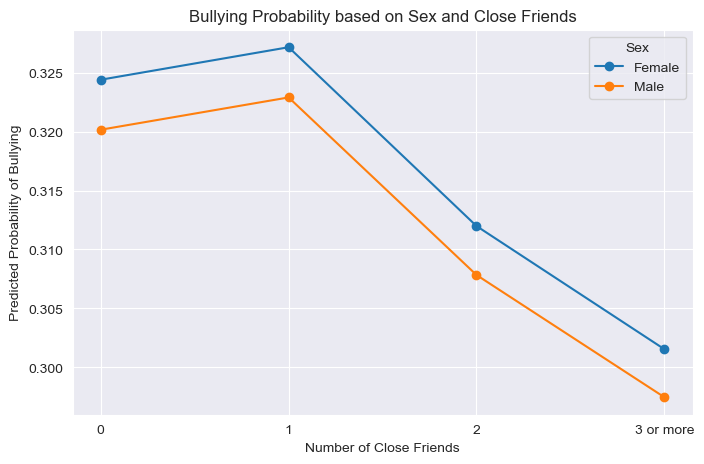

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

friend_categories = sorted(df_clean['Close Friends'].unique())
sex_categories = df_clean['Sex'].unique()

plt.figure(figsize=(8,5))

for sex in sex_categories:
    probs = []

    for friend in friend_categories:
        x_df = pd.DataFrame([np.zeros(len(X.columns))], columns=X.columns)

        # Set sex
        if f"Sex_{sex}" in X.columns:
            x_df[f"Sex_{sex}"] = 1

        # Set friends
        if f"Close Friends_{friend}" in X.columns:
            x_df[f"Close Friends_{friend}"] = 1

        # --- HOLD EVERYTHING ELSE CONSTANT ---

        # Age (example: 14)
        for col in X.columns:
            if col.startswith("Age_"):
                x_df[col] = 0
        if "Age_14 years old" in X.columns:
            x_df["Age_14 years old"] = 1

        # Loneliness (example: 3)
        if "Felt Lonely_3" in X.columns:
            x_df["Felt Lonely_3"] = 1

        # Kindness (example: 3)
        if "Other Students Kind and Helpful_3" in X.columns:
            x_df["Other Students Kind and Helpful_3"] = 1

        # Predict
        prob = model.predict_proba(x_df)[0,1]
        probs.append(prob)

    plt.plot(friend_categories, probs, marker='o', label=sex)

plt.xlabel('Number of Close Friends')
plt.ylabel('Predicted Probability of Bullying')
plt.title('Bullying Probability based on Sex and Close Friends')
plt.legend(title='Sex')
plt.grid(True)
plt.show()

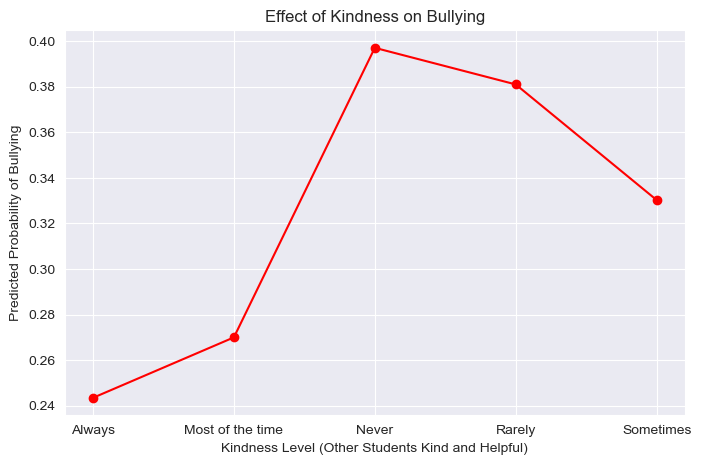

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Get kindness levels
kindness_levels = sorted(df_clean['Other Students Kind and Helpful'].unique())

probs = []

for k in kindness_levels:
    # Start with zeros
    x_df = pd.DataFrame([np.zeros(len(X.columns))], columns=X.columns)

    # Set kindness
    if f"Other Students Kind and Helpful_{k}" in X.columns:
        x_df[f"Other Students Kind and Helpful_{k}"] = 1

    # Hold other variables constant
    # Example: Age = 14
    for col in X.columns:
        if col.startswith("Age_"):
            x_df[col] = 0
    if "Age_14 years old" in X.columns:
        x_df["Age_14 years old"] = 1

    # Example: Sex = Female
    if "Sex_Female" in X.columns:
        x_df["Sex_Female"] = 1

    # Example: Close Friends = 3
    if "Close Friends_3" in X.columns:
        x_df["Close Friends_3"] = 1

    # Example: Loneliness = 3
    if "Felt Lonely_3" in X.columns:
        x_df["Felt Lonely_3"] = 1

    # Predict probability
    prob = model.predict_proba(x_df)[0,1]
    probs.append(prob)

# Plot
plt.figure(figsize=(8,5))
plt.plot(kindness_levels, probs, marker='o', color='red')
plt.xlabel('Kindness Level (Other Students Kind and Helpful)')
plt.ylabel('Predicted Probability of Bullying')
plt.title('Effect of Kindness on Bullying')
plt.grid(True)
plt.show()

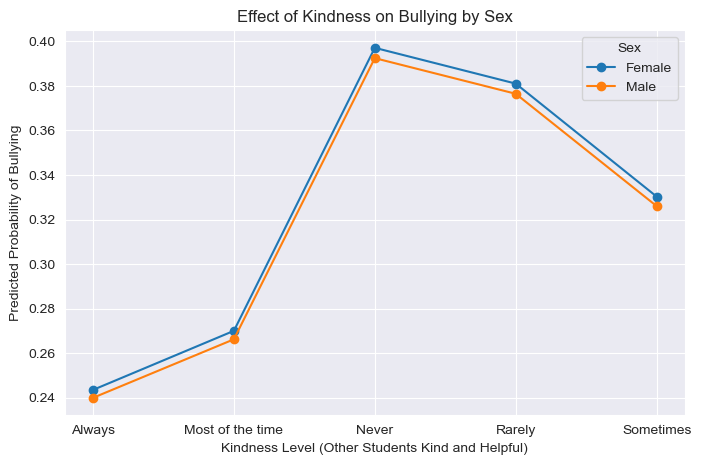

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Kindness levels
kindness_levels = sorted(df_clean['Other Students Kind and Helpful'].unique())
sex_categories = df_clean['Sex'].unique()

plt.figure(figsize=(8,5))

for sex in sex_categories:
    probs = []

    for k in kindness_levels:
        # Start with zeros
        x_df = pd.DataFrame([np.zeros(len(X.columns))], columns=X.columns)

        # Set kindness
        if f"Other Students Kind and Helpful_{k}" in X.columns:
            x_df[f"Other Students Kind and Helpful_{k}"] = 1

        # Set sex
        for col in X.columns:
            if col.startswith("Sex_"):
                x_df[col] = 0
        if f"Sex_{sex}" in X.columns:
            x_df[f"Sex_{sex}"] = 1

        # Hold other variables constant
        # Age = 14
        for col in X.columns:
            if col.startswith("Age_"):
                x_df[col] = 0
        if "Age_14 years old" in X.columns:
            x_df["Age_14 years old"] = 1

        # Close Friends = 3
        for col in X.columns:
            if col.startswith("Close Friends_"):
                x_df[col] = 0
        if "Close Friends_3" in X.columns:
            x_df["Close Friends_3"] = 1

        # Loneliness = 3
        for col in X.columns:
            if col.startswith("Felt Lonely_"):
                x_df[col] = 0
        if "Felt Lonely_3" in X.columns:
            x_df["Felt Lonely_3"] = 1

        # Predict probability
        prob = model.predict_proba(x_df)[0,1]
        probs.append(prob)

    # Plot line for this sex
    plt.plot(kindness_levels, probs, marker='o', label=sex)

plt.xlabel('Kindness Level (Other Students Kind and Helpful)')
plt.ylabel('Predicted Probability of Bullying')
plt.title('Effect of Kindness on Bullying by Sex')
plt.legend(title='Sex')
plt.grid(True)
plt.show()

In [52]:
print(model.classes_)
print(np.bincount(y_train))

[False  True]
[29128  7820]


In [53]:
print(df_clean['Felt Lonely'].unique())

[5, 1, 2, 3, 4]
Categories (5, int64): [1 < 2 < 3 < 4 < 5]


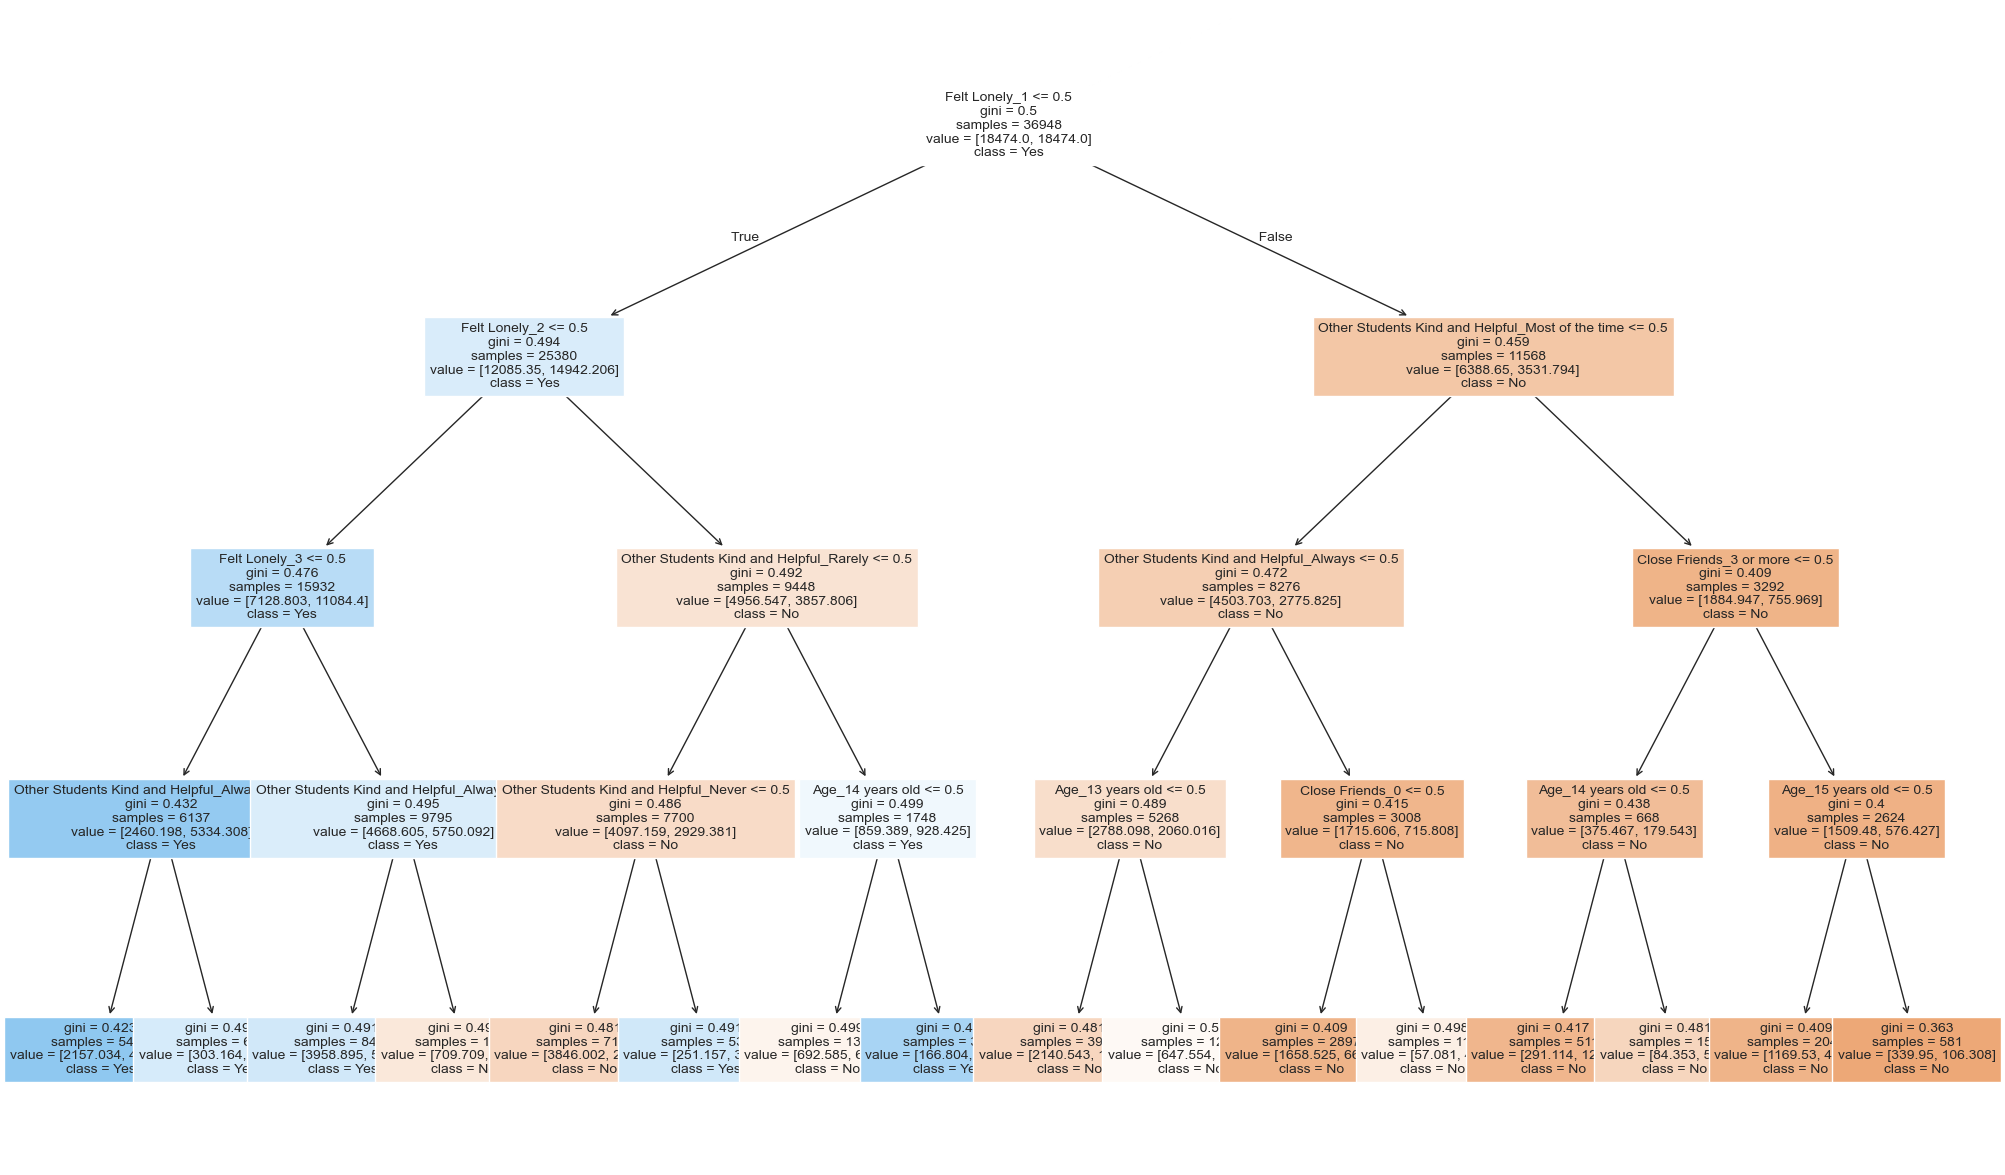

Feature importance (highest to lowest):
Felt Lonely_1                                       0.428179
Felt Lonely_2                                       0.264243
Felt Lonely_3                                       0.119147
Other Students Kind and Helpful_Always              0.083913
Other Students Kind and Helpful_Most of the time    0.026671
Other Students Kind and Helpful_Rarely              0.022760
Other Students Kind and Helpful_Never               0.021561
Age_14 years old                                    0.015894
Age_13 years old                                    0.009947
Close Friends_0                                     0.004945
Close Friends_3 or more                             0.001484
Age_15 years old                                    0.001256
Close Friends_1                                     0.000000
Other Students Kind and Helpful_Sometimes           0.000000
Close Friends_2                                     0.000000
Age_12 years old                             

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Select features (all student characteristics)
feature_cols = ['Felt Lonely', 'Sex', 'Close Friends', 'Other Students Kind and Helpful'] + \
               [col for col in df_clean.columns if col.startswith('Age_')]
X = df_clean[feature_cols]
y = df_clean['Bullied_on_school_property_in_past_12_months']

# 2. Encode categorical variables
X = pd.get_dummies(X, columns=['Felt Lonely', 'Sex', 'Close Friends', 'Other Students Kind and Helpful'])
y = pd.get_dummies(y, drop_first=True).squeeze()  # converts target to 0/1

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 4. Train decision tree
model = DecisionTreeClassifier(
    max_depth=4,            # keep tree interpretable
    min_samples_leaf=100,   # avoid tiny splits
    class_weight='balanced',
    random_state=42
)
model.fit(X_train, y_train)


# 5. Plot tree
plt.figure(figsize=(25,15))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True,
    fontsize=10
)
plt.show()

# 6. Feature importance
importance = pd.Series(model.feature_importances_, index=X.columns)
print("Feature importance (highest to lowest):")
print(importance.sort_values(ascending=False))

In [55]:
df_clean.groupby('Felt Lonely')['Bullied_on_school_property_in_past_12_months'].mean()

/var/folders/d_/q8kb65gs01g9l_cr95bp1_9w0000gn/T/ipykernel_97803/3392434777.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby('Felt Lonely')['Bullied_on_school_property_in_past_12_months'].mean()


Felt Lonely
1    0.129810
2    0.173868
3    0.246009
4    0.349476
5    0.412032
Name: Bullied_on_school_property_in_past_12_months, dtype: float64

In [56]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [57]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']

In [58]:
import joblib

model = joblib.load("model.pkl")
joblib.dump(X.columns, "model_columns.pkl")

['model_columns.pkl']

In [59]:
print(X.columns)


Index(['Age_12 years old', 'Age_13 years old', 'Age_14 years old',
       'Age_15 years old', 'Age_16 years old', 'Age_17 years old',
       'Age_18 years old or older', 'Felt Lonely_1', 'Felt Lonely_2',
       'Felt Lonely_3', 'Felt Lonely_4', 'Felt Lonely_5', 'Sex_Female',
       'Sex_Male', 'Close Friends_0', 'Close Friends_1', 'Close Friends_2',
       'Close Friends_3 or more', 'Other Students Kind and Helpful_Never',
       'Other Students Kind and Helpful_Rarely',
       'Other Students Kind and Helpful_Sometimes',
       'Other Students Kind and Helpful_Most of the time',
       'Other Students Kind and Helpful_Always'],
      dtype='object')


In [60]:
import joblib

X_columns = joblib.load("model_columns.pkl")
print([c for c in X_columns if "Close Friends" in c])

['Close Friends_0', 'Close Friends_1', 'Close Friends_2', 'Close Friends_3 or more']


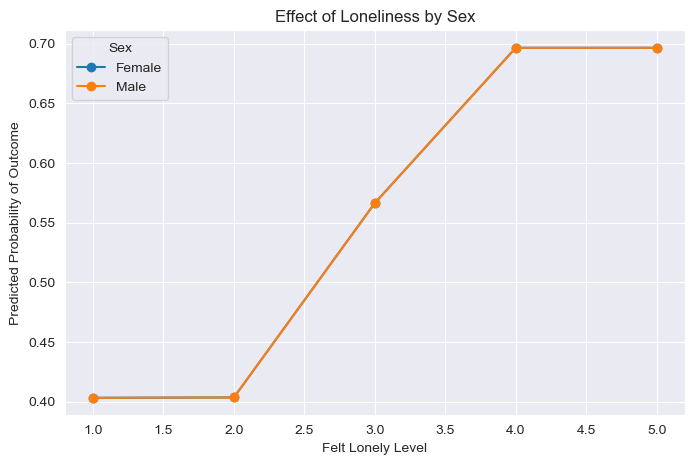

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

loneliness_levels = sorted(df_clean['Felt Lonely'].unique())
sex_categories = df_clean['Sex'].unique()

plt.figure(figsize=(8,5))

for sex in sex_categories:
    probs = []

    for l in loneliness_levels:

        x_df = pd.DataFrame([np.zeros(len(X.columns))], columns=X.columns)

        # Set loneliness (ONLY variable you're studying)
        if f"Felt Lonely_{l}" in X.columns:
            x_df[f"Felt Lonely_{l}"] = 1

        # Set sex
        for col in X.columns:
            if col.startswith("Sex_"):
                x_df[col] = 0
        if f"Sex_{sex}" in X.columns:
            x_df[f"Sex_{sex}"] = 1

        # Keep others constant (fine)
        if "Age_14 years old" in X.columns:
            x_df["Age_14 years old"] = 1

        if "Close Friends_3 or more" in X.columns:
            x_df["Close Friends_3 or more"] = 1



        prob = model.predict_proba(x_df)[0,1]
        probs.append(prob)

    plt.plot(loneliness_levels, probs, marker='o', label=sex)

plt.xlabel('Felt Lonely Level')
plt.ylabel('Predicted Probability of Outcome')
plt.title('Effect of Loneliness by Sex')
plt.legend(title='Sex')
plt.grid(True)
plt.show()